In [1]:
# Chapter 6 Practice

In [6]:
# Gaussian Elim by Hand, no pivot

import numpy as np

A = np.array([[1,2,3,4],
         [4,2,4,3],
         [5,3,7,6],
         [8,2,3,1]], float
         )
v = np.array([2,4,3,5],float)
N = len(v) 

# Implement Gaussian Scheme

for i in range(N):
    div = A[i,i] # grab the diagonal element
    A[i,:] /= div # divide row by diagonal element, iterate over all rows, and full row
    v[i] /= div # do the same to vector

    # Now also in the above for loop, we need to create an UTM, and so subtract the diag 1, from rows
    for k in range(i+1,N): # use range start stop where we start one row below and stop at last row
        mult = A[k,i]
        A[k,:] -= mult*A[i,:]
        v[k] -= mult*v[i]

# now create the backsub that solves the system
x = np.empty(N,float)
for m in range(N-1,-1,-1): # this iterates m starting from 3, to 2,1,0 (start, stop, iteration step) and thus starts bottom
    x[m] = v[m]
    for j in range(m+1,N):
        x[m] -= A[m,j]*x[j]

print(x)



[-1.36363636  7.18181818  1.90909091 -4.18181818]


In [13]:
# The linear algebra np module:
import numpy as np


A = np.array([[1,2,3,4],
         [4,2,4,3],
         [5,3,7,6],
         [8,2,3,1]], float
         )
v = np.array([2,4,3,5],float)


# SOLVE A LINEAR EQUATION - uses lU decomposition

x = np.linalg.solve(A,v)
print(f"The solution to the linear equation Ax=v is{x}")

# advanced matrix ops:

inverse = np.linalg.inv(A)
determinant = np.linalg.det(A)

# np has basic operations:
"""
inner/outer product, matrix mult, transpose, trace, and norm
"""


# SOLVE FOR EIGENVECTOR AND EIGENVALUE - approximate method, QR Algorithm
x,V = np.linalg.eigh(A) # can use eig, eigh (herm or symmetric), 
                        # or just eigvals/eigvalsh for values only
print(f"The eigenvalues of A are: {x}")
print(f"The eigenvectors of A are: {V}")


The solution to the linear equation Ax=v is[-1.36363636  7.18181818  1.90909091 -4.18181818]
The eigenvalues of A are: [-7.35189686  0.15339292  2.41594028 15.78256366]
The eigenvectors of A are: [[-0.74456756  0.13617814  0.35319335 -0.54984463]
 [ 0.15089938 -0.91471301  0.11567415 -0.35657956]
 [ 0.09333506  0.14772131 -0.78514907 -0.5941447 ]
 [ 0.64353484  0.35061951  0.49539368 -0.46638394]]


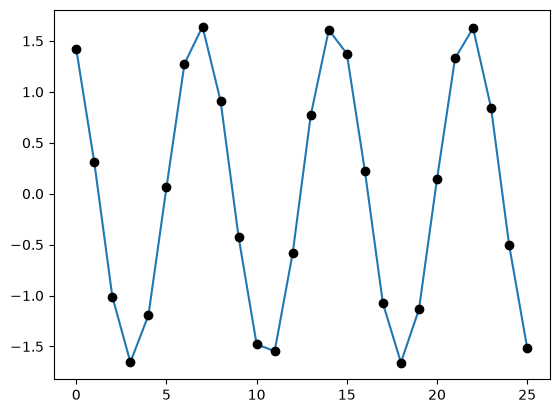

In [18]:
# TYPES OF MATRICES - TRIDIAGONAL AND BANDED
"""
when matrices get large, the operations on all the zeros add up,
may not need all that data, so for close to diagonal matrices, such as banded and tridiagonal, 
a Gaussian elim still works best, while not operating on the many zeros
"""
# Example 6.2: masses on springs in 1D

import numpy as np
import matplotlib.pyplot as plt

# Constants of the setup: 
N = 26
C = 1.0
m = 1.0 
k = 6.0
omega = 2.0
alpha = 2*k-m*omega*omega

# Set up initial values of the arrays
A = np.zeros([N,N],float)
for i in range(N-1):
    A[i,i] = alpha
    A[i,i+1] = -k
    A[i+1,i] = -k

A[0,0] = alpha-k
A[N-1,N-1] = alpha-k
v = np.zeros(N,float)
v[0] = C

# Now do Gaussian Elim: 

for i in range(N-1):
    A[i,i+1] /= A[i,i]
    v[i] /= A[i,i]

    A[i+1,i+1]-= A[i+1,i]*A[i,i+1]
    v[i+1] -= A[i+1,i]*v[i]

v[N-1] /= A[N-1,N-1]

# now backsub
x = np.empty(N,float)
x[N-1] = v[N-1]
for i in range(N-2,-1,-1):
    x[i] = v[i] - A[i,i+1]*x[i+1]

plt.plot(x)
plt.plot(x,"ko")
plt.show()

"""
Gauss elim except we only deal with the diagonal, and one up one down diagonal rows, so avoid iterating or operating
on the entire matrix saves time, a similar code can be written for banded (more than one off the diagonal) just by extending the i+1 to 
the appropriate diagonal strips
"""
    

In [ ]:
"""
Moving now to Nonlinear Equations
"""

In [26]:
# Nonlinear Equations: Methods

# start with a function that cannot be solved analytically
import numpy as np

# initialize a starting x value guess
x = 1.0
for _ in range(10):
    x = 2-np.exp(-x)
    print(x)

y = 0.5
for _ in range(10):
    y = np.sqrt(1-np.log(y))
    print(y)
    

1.6321205588285577
1.8044854658474119
1.8354408939220457
1.8404568553435368
1.841255113911434
1.8413817828128696
1.8414018735357267
1.8414050598547234
1.8414055651879888
1.8414056453310121
1.3012098910475378
0.8583154914892762
1.0736775779454883
0.9637999044091371
1.0182689104343374
0.990906635925747
1.004557096969838
0.997724037576543
1.0011386299421705
0.9994308469350205


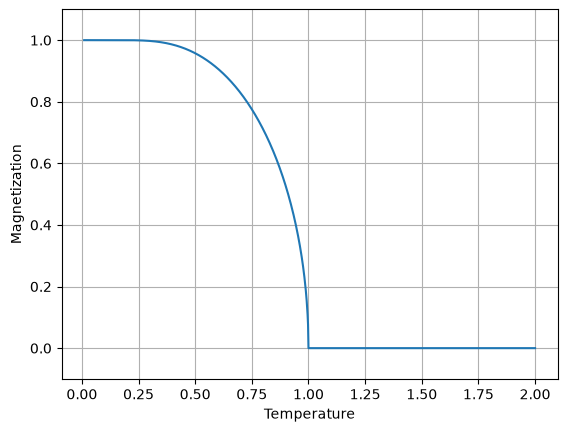

In [30]:
# RELAXATION METHOD PHYSICS EXAMPLE:

"""
solving a mean field ferromagentism problem where we have m = tanh(Cm/T), and an error function
"""

import numpy as np
import matplotlib.pyplot as plt
from math import tanh, cosh

# Constants:
Tmax = 2.0
points = 1000
accuracy = 1e-6

# set up the lists for plotting:
y = []
temp = np.linspace(0.01,Tmax,points)

#Temperature loop:
for T in temp:
    m1 = 1.0
    error = 1.0

    # loop till error is smaller than accuracy:
    while error>accuracy:
        m1,m2 = tanh(m1/T),m1
        error = abs((m1-m2)/(1-T*cosh(m2/T)**2))
    y.append(m1)

plt.plot(temp,y)
plt.ylim(-0.1,1.1)
plt.xlabel("Temperature")
plt.ylabel("Magnetization")
plt.grid()
plt.show()

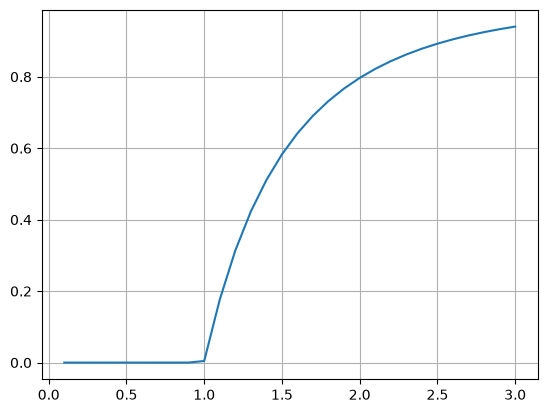

In [49]:
# Another relaxation method:

import numpy as np
import matplotlib.pyplot as plt

def f(x,c=2):
    return 1-np.exp(-c*x)

def rel_meth(func,initial_x=1,eps=1e-5,max_steps=1000):
    x = initial_x
    for _ in range(max_steps):
        x_new = func(x)
        if abs(x_new-x) < eps:
            return float(x_new)
        x = x_new
    return x
        
# now we want to change c to be values 0.1 to 3.0, and graph c and x(c):

def plot_data():
    c = np.arange(0.1,3.1,0.1)
    x_data = np.empty(len(c),float)

    for i in range(len(c)):
        var = rel_meth(lambda x: f(x,c[i]))
        x_data[i] = var
        
        

    plt.plot(c,x_data)
    plt.grid()
    plt.show()

plot_data()


        
    
        
    